# Klasifikasi Tipe Kepribadian Berdasarkan Karakteristik Individu Menggunakan Algoritma Machine Learning

#### 1. Data Understanding

Dataset yang digunakan berasal dari Kaggle dengan judul "Predict People Personality Types" yang berisi data kepribadian untuk memprediksi tipe MBTI.
[Link Dataset](https://www.kaggle.com/datasets/stealthtechnologies/predict-people-personality-types)

Dataset ini terdiri dari 9 kolom dan 43.744 baris data responden.

In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/data.csv")

In [47]:
df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,21.0,Female,1,5.89208,2.144395,7.32363,5.462224,Arts,ENTP
1,24.0,Female,1,2.48366,3.206188,8.06876,3.765012,Unknown,INTP
2,26.0,Female,1,7.02910,6.469302,4.16472,5.454442,Others,ESFP
3,30.0,Male,0,5.46525,4.179244,2.82487,5.080477,Sports,ENFJ
4,31.0,Female,0,3.59804,6.189259,5.31347,3.677984,Others,ISFP


Dari 5 baris pertama, terlihat bahwa dataset memiliki 9 kolom. Kolom `Age` bertipe float, `Gender` dan `Interest` berupa kategorikal (teks), `Education` berupa binary (0/1), serta empat kolom skor psikometri (`Introversion`, `Sensing`, `Thinking`, `Judging`) yang masing-masing memiliki rentang 0–10. Kolom target `Personality` berisi kode MBTI 4 huruf.

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43744 entries, 0 to 43743
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 43744 non-null  float64
 1   Gender              43744 non-null  str    
 2   Education           43744 non-null  int64  
 3   Introversion Score  43744 non-null  float64
 4   Sensing Score       43744 non-null  float64
 5   Thinking Score      43744 non-null  float64
 6   Judging Score       43744 non-null  float64
 7   Interest            43744 non-null  str    
 8   Personality         43744 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 3.6 MB


Dataset terdiri dari **43.744 baris** dan **9 kolom**. Tidak ada missing value karena semua kolom memiliki 43.744 non-null entries. Terdapat 5 kolom bertipe float64 (Age dan 4 skor psikometri), 1 kolom integer (Education), dan 3 kolom string (Gender, Interest, Personality). Total penggunaan memori sekitar 3.6 MB.

**Deskripsi Fitur:**

- **Age**: Usia responden
- **Gender**: Jenis kelamin (Male / Female)
- **Education**: Tingkat pendidikan (0 = SMA/S1, 1 = Pascasarjana)
- **Introversion Score**: Skor kecenderungan introvert-ekstrovert (0–10)
- **Sensing Score**: Skor preferensi sensing vs intuition (0–10)
- **Thinking Score**: Skor preferensi thinking vs feeling (0–10)
- **Judging Score**: Skor preferensi judging vs perceiving (0–10)
- **Interest**: Minat utama responden (Arts, Sports, Technology, Others, Unknown)
- **Personality**: Tipe kepribadian MBTI (16 kelas target)

In [49]:
df.describe()

,Age,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score
count,43744.000000,43744.000000,43744.000000,43744.000000,43744.000000,43744.000000
mean,27.437203,0.229014,4.588349,5.780074,5.419131,5.391041
std,4.893805,0.420203,2.902628,1.241648,2.900785,1.442413
min,18.000000,0.000000,0.000150,0.000000,0.000320,0.000000
25%,24.000000,0.000000,2.067020,4.953340,2.895750,4.511842
50%,27.000000,0.000000,4.261680,6.162928,5.769870,5.771635
75%,30.000000,0.000000,7.085002,6.622978,7.923503,6.409583
max,52.000000,1.000000,9.999920,9.803837,9.999770,10.000000


Dari statistik deskriptif:
- **Age**: Rentang usia 18–52 tahun dengan rata-rata 27.4 tahun dan standar deviasi 4.89
- **Education**: Mayoritas responden berpendidikan SMA/S1 (mean=0.23, artinya hanya ~23% yang pascasarjana)
- **Introversion Score**: Tersebar cukup merata (mean=4.59, std=2.90) di rentang 0–10
- **Sensing Score**: Cenderung di atas rata-rata (mean=5.78) dengan variasi yang lebih kecil (std=1.24)
- **Thinking Score**: Distribusi mirip Introversion (mean=5.42, std=2.90)
- **Judging Score**: Nilai tengah cenderung ke atas (mean=5.39, std=1.44)

In [50]:
# Distribusi kelas target
df['Personality'].value_counts()

Personality
ENTP    2734
INTP    2734
ESFP    2734
ENFJ    2734
ISFP    2734
ISFJ    2734
ESTJ    2734
INFP    2734
ESTP    2734
ENFP    2734
INTJ    2734
ESFJ    2734
ISTJ    2734
INFJ    2734
ISTP    2734
ENTJ    2734
Name: count, dtype: int64

Distribusi kelas target **seimbang sempurna**: setiap tipe MBTI memiliki tepat **2.734 responden**. Ini berarti dataset tidak memerlukan teknik balancing seperti SMOTE atau oversampling. Probabilitas tebakan acak adalah 1/16 = **6.25%**, sehingga akurasi model yang jauh di atas angka ini menunjukkan bahwa model benar-benar belajar dari fitur yang ada.

In [51]:
# Cek variasi isi kolom kategorikal
kolom_teks = ['Gender', 'Interest', 'Personality']

for kolom in kolom_teks:
    total_variasi = df[kolom].nunique()
    daftar_isi = df[kolom].unique()
    print(f"Kolom '{kolom}' memiliki {total_variasi} variasi: {daftar_isi}")
    print("-" * 50)

Kolom 'Gender' memiliki 2 variasi: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Kolom 'Interest' memiliki 5 variasi: <ArrowStringArray>
['Arts', 'Unknown', 'Others', 'Sports', 'Technology']
Length: 5, dtype: str
--------------------------------------------------
Kolom 'Personality' memiliki 16 variasi: <ArrowStringArray>
['ENTP', 'INTP', 'ESFP', 'ENFJ', 'ISFP', 'ISFJ', 'ESTJ', 'INFP', 'ESTP',
 'ENFP', 'INTJ', 'ESFJ', 'ISTJ', 'INFJ', 'ISTP', 'ENTJ']
Length: 16, dtype: str
--------------------------------------------------


Kolom kategorikal:
- **Gender**: 2 kategori (Male, Female)
- **Interest**: 5 kategori (Arts, Sports, Technology, Others, Unknown)
- **Personality**: 16 kategori (tipe MBTI: ISTJ, ISFJ, INFJ, INTJ, ISTP, ISFP, INFP, INTP, ESTP, ESFP, ENFP, ENTP, ESTJ, ESFJ, ENFJ, ENTJ)

Kolom Gender bisa di-encode menggunakan Label Encoding karena hanya memiliki 2 nilai. Sedangkan Interest perlu menggunakan One-Hot Encoding agar tidak ada urutan hierarkis antar kategori.

### 2. Data Preprocessing

In [52]:
# Cek missing value
df.isnull().sum()

Age                   0
Gender                0
Education             0
Introversion Score    0
Sensing Score         0
Thinking Score        0
Judging Score         0
Interest              0
Personality           0
dtype: int64

Tidak ditemukan missing value pada seluruh kolom. Dataset ini sudah lengkap sehingga tidak perlu dilakukan imputasi atau penghapusan baris.

In [53]:
# Cek dan hapus data duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape setelah drop duplikat: {df.shape}")

Jumlah duplikat: 1028
Shape setelah drop duplikat: (42716, 9)


Ditemukan **1.028 baris duplikat** yang kemudian dihapus. Setelah pembersihan, dataset menjadi **42.716 baris**. Penghapusan duplikat penting agar model tidak belajar dari data yang sama berulang kali, yang dapat menyebabkan bias pada evaluasi.

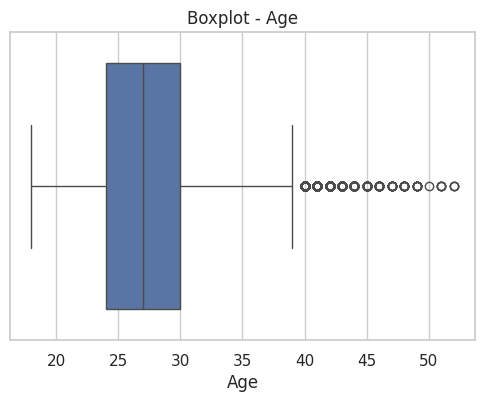

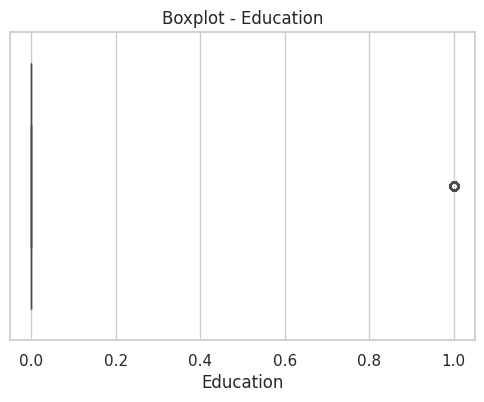

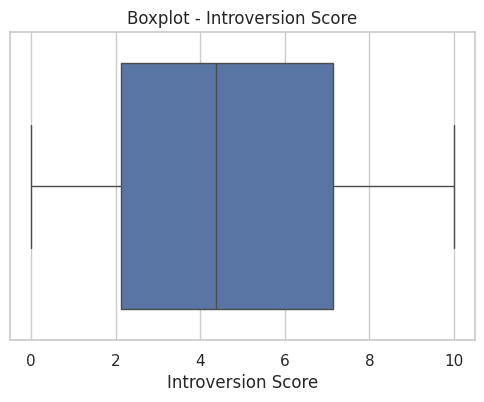

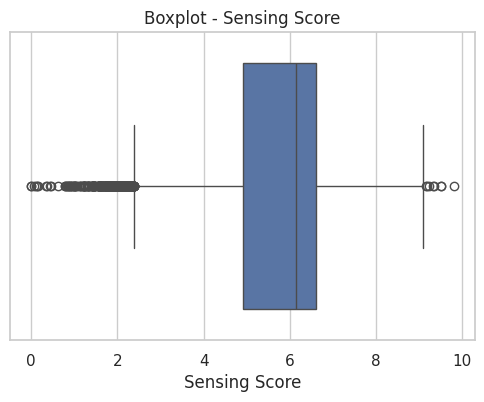

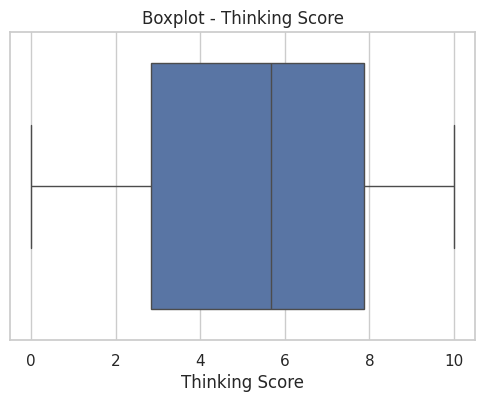

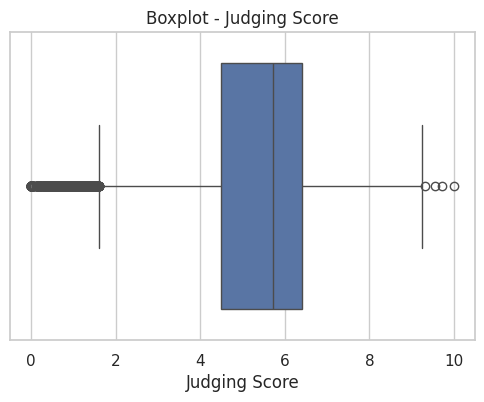

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

df_num = df.select_dtypes(include=[np.number])

for col in df_num.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

Dari visualisasi boxplot, terlihat bahwa beberapa kolom memiliki outlier terutama pada `Age` dan `Sensing Score`. Namun setelah eksperimen lebih lanjut (dibahas pada cell berikutnya), outlier ini diputuskan untuk dipertahankan.

In [55]:
# Analisis Outlier
# Berdasarkan hasil eksplorasi boxplot, ditemukan beberapa outlier pada kolom numerik.
# Namun setelah dilakukan eksperimen, penghapusan outlier justru menurunkan akurasi model
# karena data outlier pada dataset psikometri ini merepresentasikan variasi alami
# perilaku manusia, bukan noise. Oleh karena itu, outlier dipertahankan.

print(f"Total data setelah pembersihan duplikat: {len(df)} baris")
print("Outlier dipertahankan untuk menjaga variasi informasi data.")

Total data setelah pembersihan duplikat: 42716 baris
Outlier dipertahankan untuk menjaga variasi informasi data.


In [56]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding untuk Gender (binary: Female=0, Male=1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding untuk Interest
df = pd.get_dummies(df, columns=['Interest'], drop_first=True, dtype=int)

df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Personality,Interest_Others,Interest_Sports,Interest_Technology,Interest_Unknown
0,21.0,0,1,5.89208,2.144395,7.32363,5.462224,ENTP,0,0,0,0
1,24.0,0,1,2.48366,3.206188,8.06876,3.765012,INTP,0,0,0,1
2,26.0,0,1,7.02910,6.469302,4.16472,5.454442,ESFP,1,0,0,0
3,30.0,1,0,5.46525,4.179244,2.82487,5.080477,ENFJ,0,1,0,0
4,31.0,0,0,3.59804,6.189259,5.31347,3.677984,ISFP,1,0,0,0


Proses encoding:
- **Gender**: Diubah menggunakan Label Encoding (Female=0, Male=1) karena hanya memiliki 2 kategori
- **Interest**: Diubah menggunakan One-Hot Encoding dengan `drop_first=True`, menghasilkan 4 kolom baru (`Interest_Others`, `Interest_Sports`, `Interest_Technology`, `Interest_Unknown`). Kategori `Arts` menjadi baseline (semua kolom bernilai 0)

Setelah encoding, jumlah fitur bertambah dari 9 menjadi 11 kolom (tidak termasuk kolom target).

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standarisasi hanya pada kolom numerik kontinu
kolom_skala = ['Age', 'Introversion Score', 'Sensing Score', 'Thinking Score', 'Judging Score']
df[kolom_skala] = scaler.fit_transform(df[kolom_skala])

df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Personality,Interest_Others,Interest_Sports,Interest_Technology,Interest_Unknown
0,-1.306925,0,1,0.428229,-2.901054,0.677646,0.065958,ENTP,0,0,0,0
1,-0.694292,0,1,-0.745605,-2.048563,0.934453,-1.106094,INTP,0,0,0,1
2,-0.285870,0,1,0.819810,0.571323,-0.411064,0.060583,ESFP,1,0,0,0
3,0.530975,1,0,0.281232,-1.267317,-0.872839,-0.197667,ENFJ,0,1,0,0
4,0.735186,0,0,-0.361821,0.346482,-0.015150,-1.166194,ISFP,1,0,0,0


Standarisasi Z-Score (`StandardScaler`) diterapkan pada 5 kolom numerik kontinu: `Age`, `Introversion Score`, `Sensing Score`, `Thinking Score`, dan `Judging Score`. Setelah scaling, setiap kolom memiliki rata-rata ≈ 0 dan standar deviasi ≈ 1. Kolom binary (Gender, Education, dan hasil One-Hot Encoding) tidak perlu di-scale karena sudah dalam skala 0/1.

### 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_59503/838616922.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Personality', palette='rainbow', order=df['Personality'].value_counts().index)


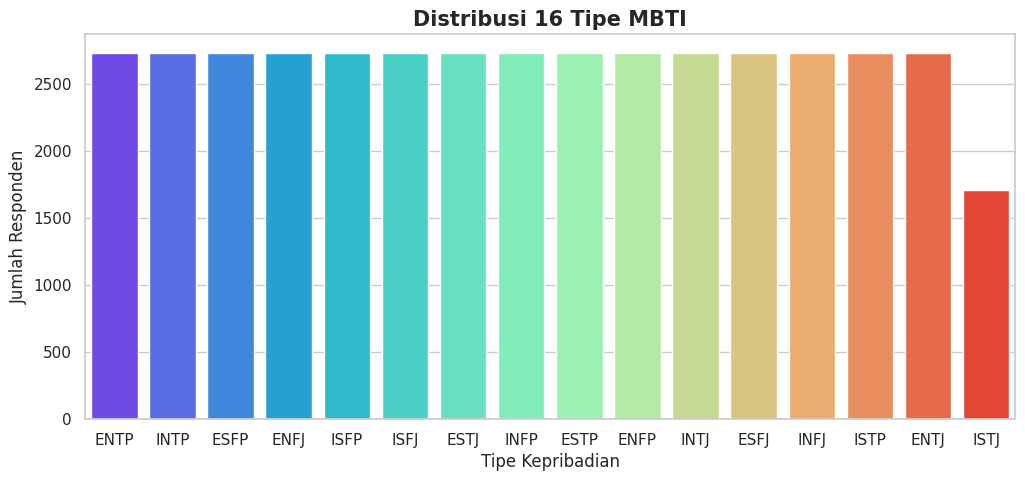

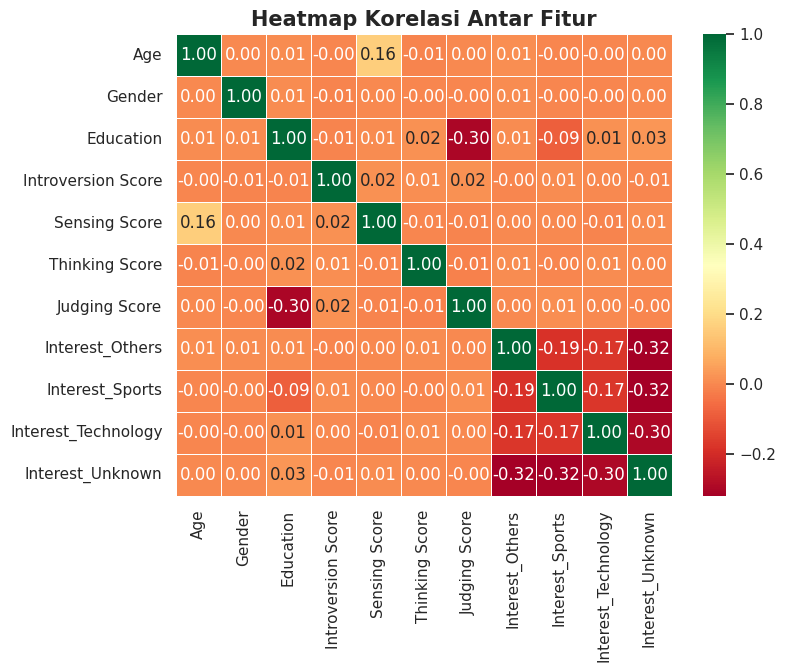

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Distribusi kelas target
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Personality', palette='rainbow', order=df['Personality'].value_counts().index)
plt.title('Distribusi 16 Tipe MBTI', fontsize=15, fontweight='bold')
plt.ylabel('Jumlah Responden')
plt.xlabel('Tipe Kepribadian')
plt.show()

# Heatmap korelasi
plt.figure(figsize=(8, 6))
kolom_angka = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(kolom_angka.corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=15, fontweight='bold')
plt.show()

Dari visualisasi EDA:
- **Distribusi target**: Semua 16 tipe MBTI memiliki jumlah yang seimbang, sehingga tidak ada class imbalance
- **Heatmap korelasi**: Tidak terlihat korelasi kuat antar fitur (nilai korelasi mendekati 0), yang menandakan bahwa setiap fitur memberikan informasi yang independen. Tidak perlu dilakukan reduksi dimensi atau penghapusan fitur karena multikolinearitas.

### 4. Data Splitting   

In [59]:
X = df.drop('Personality', axis=1)
y = df['Personality']

print(f"Jumlah fitur: {len(X.columns)}")

Jumlah fitur: 11


Data dipisahkan menjadi **X** (11 fitur input) dan **y** (kolom target `Personality`). Fitur input terdiri dari: Age, Gender, Education, 4 skor psikometri, dan 4 kolom One-Hot Interest.

In [60]:
from sklearn.model_selection import train_test_split

data_splits = {}

# Split 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=120, stratify=y)
data_splits['70:30'] = (X_train_70, X_test_30, y_train_70, y_test_30)

# Split 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=120, stratify=y)
data_splits['80:20'] = (X_train_80, X_test_20, y_train_80, y_test_20)

# Split 90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X, y, test_size=0.10, random_state=120, stratify=y)
data_splits['90:10'] = (X_train_90, X_test_10, y_train_90, y_test_10)

print(f"Total data: {len(X)} baris")
print(f"[70:30] Train: {len(X_train_70):,} | Test: {len(X_test_30):,}")
print(f"[80:20] Train: {len(X_train_80):,} | Test: {len(X_test_20):,}")
print(f"[90:10] Train: {len(X_train_90):,} | Test: {len(X_test_10):,}")

Total data: 42716 baris
[70:30] Train: 29,901 | Test: 12,815
[80:20] Train: 34,172 | Test: 8,544
[90:10] Train: 38,444 | Test: 4,272


Data dibagi menjadi 3 variasi rasio train-test untuk membandingkan pengaruh jumlah data latih terhadap performa model. Parameter `stratify=y` memastikan proporsi 16 kelas MBTI tetap seimbang di setiap subset train dan test.

### 5. Model Building

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

models = {
    'Logistic Regression': LogisticRegression(random_state=120, max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(random_state=120),
    'Random Forest': RandomForestClassifier(random_state=120, n_jobs=-1),
}

le_xgb = LabelEncoder()
hasil_awal_akurasi = {}

for nama_rasio, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n=== Rasio {nama_rasio} ===")
    le_xgb.fit(y_train)

    for nama_model, algoritma in models.items():
        if nama_model == 'XGBoost':
            y_train_saji = le_xgb.transform(y_train)
            y_test_saji = le_xgb.transform(y_test)
        else:
            y_train_saji = y_train
            y_test_saji = y_test

        algoritma.fit(X_train, y_train_saji)
        predict = algoritma.predict(X_test)
        nilai_akurasi = accuracy_score(y_test_saji, predict)

        print(f"   {nama_model:<20} : {nilai_akurasi * 100:.2f}%")
        hasil_awal_akurasi[f"{nama_model} ({nama_rasio})"] = nilai_akurasi


=== Rasio 70:30 ===
   Logistic Regression  : 84.80%
   Decision Tree        : 86.23%
   Random Forest        : 89.26%

=== Rasio 80:20 ===
   Logistic Regression  : 84.81%
   Decision Tree        : 85.77%
   Random Forest        : 89.34%

=== Rasio 90:10 ===
   Logistic Regression  : 85.14%
   Decision Tree        : 86.75%
   Random Forest        : 90.10%


Pada tahap ini, 3 algoritma diuji secara baseline (tanpa tuning) di semua rasio split. Algoritma yang digunakan:
- **Logistic Regression**: Model linear yang cocok sebagai baseline untuk klasifikasi
- **Decision Tree**: Model non-linear berbasis pohon keputusan
- **Random Forest**: Ensemble dari banyak decision tree (bagging)

Dari hasil baseline, terlihat bahwa rasio 90:10 menghasilkan akurasi tertinggi karena model memiliki lebih banyak data untuk belajar.

### 6. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

X_train, X_test, y_train, y_test = data_splits['90:10']

# Logistic Regression
param_lr = {'C': [0.1, 1, 10, 100], 'solver': ['lbfgs', 'newton-cg']}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=2000), param_lr, cv=3, n_jobs=-1)
grid_lr.fit(X_train, y_train)
lr_juara = grid_lr.best_estimator_

# Decision Tree
param_dt = {'max_depth': [10, 30, 50, None], 'min_samples_leaf': [1, 2, 4]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=3, n_jobs=-1)
grid_dt.fit(X_train, y_train)
dt_juara = grid_dt.best_estimator_

# Random Forest
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20],
    'min_samples_leaf': [2, 5],
    'criterion': ['gini', 'entropy']
}
rand_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_rf, n_iter=8, cv=3, random_state=42)
rand_rf.fit(X_train, y_train)
rf_juara = rand_rf.best_estimator_

# Hasil tuning
print("=== Hasil Hyperparameter Tuning (90:10) ===")
print(f"Logistic Regression : {accuracy_score(y_test, lr_juara.predict(X_test))*100:.2f}%")
print(f"Decision Tree       : {accuracy_score(y_test, dt_juara.predict(X_test))*100:.2f}%")
print(f"Random Forest       : {accuracy_score(y_test, rf_juara.predict(X_test))*100:.2f}%")

=== Hasil Hyperparameter Tuning (90:10) ===
Logistic Regression : 86.38%
Decision Tree       : 88.53%
Random Forest       : 90.17%


Hyperparameter tuning dilakukan pada rasio 90:10 (rasio terbaik dari hasil baseline). Metode yang digunakan:
- **GridSearchCV** untuk Logistic Regression dan Decision Tree (pencarian exhaustive karena parameter space kecil)
- **RandomizedSearchCV** untuk Random Forest (pencarian random karena parameter space lebih besar)

Random Forest menunjukkan akurasi tertinggi setelah tuning, sehingga ditetapkan sebagai model final (`rf_juara`).

### 7. Model Evaluation

              precision    recall  f1-score   support

        ENFJ       0.96      0.88      0.92       274
        ENFP       0.93      0.88      0.90       274
        ENTJ       0.94      0.87      0.90       273
        ENTP       0.93      0.84      0.88       273
        ESFJ       0.91      0.93      0.92       274
        ESFP       0.89      0.92      0.90       273
        ESTJ       0.89      0.93      0.91       273
        ESTP       0.92      0.88      0.90       274
        INFJ       0.90      0.93      0.92       274
        INFP       0.90      0.90      0.90       273
        INTJ       0.91      0.90      0.90       274
        INTP       0.90      0.88      0.89       273
        ISFJ       0.89      0.95      0.92       273
        ISFP       0.86      0.93      0.89       273
        ISTJ       0.87      0.86      0.86       171
        ISTP       0.86      0.94      0.90       273

    accuracy                           0.90      4272
   macro avg       0.90   

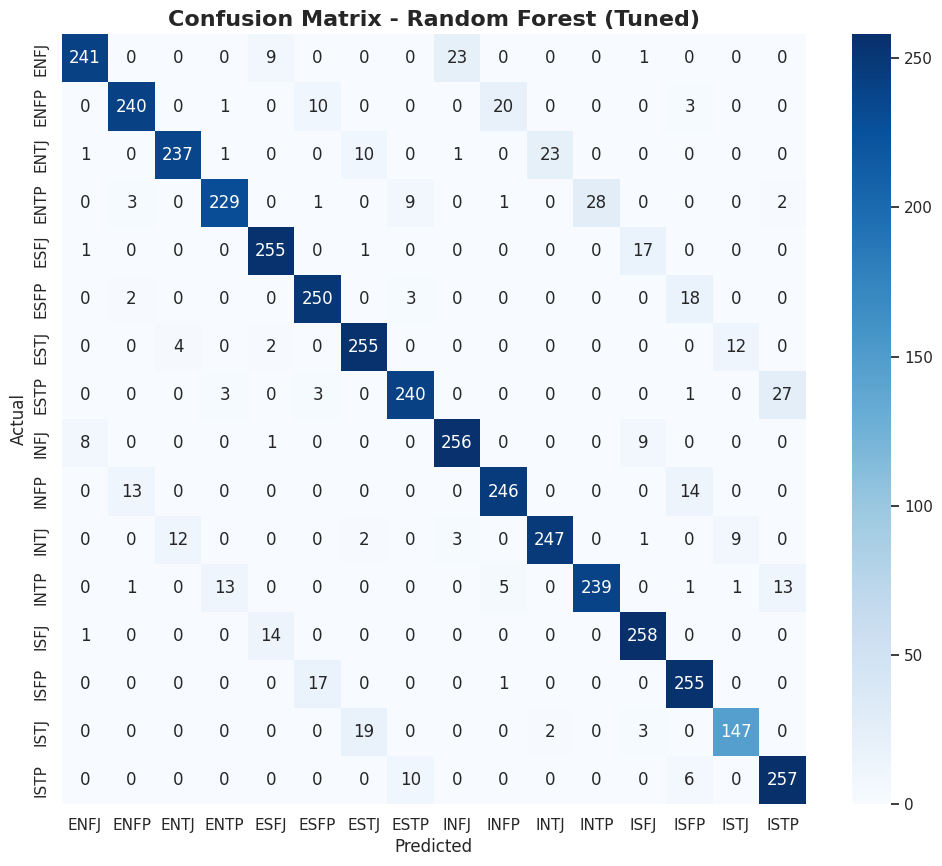

In [63]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

tebakan_final = rf_juara.predict(X_test)

# Classification Report
print(classification_report(y_test, tebakan_final))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, tebakan_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_juara.classes_, yticklabels=rf_juara.classes_)
plt.title('Confusion Matrix - Random Forest (Tuned)', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Dari classification report dan confusion matrix:
- **Precision, recall, dan F1-score** untuk setiap tipe MBTI cukup merata, menandakan model tidak bias terhadap kelas tertentu
- **Confusion matrix** menunjukkan bahwa sebagian besar prediksi benar berada di diagonal utama. Kesalahan prediksi yang terjadi umumnya antara tipe-tipe MBTI yang memiliki karakteristik serupa

### 8. Model Comparison

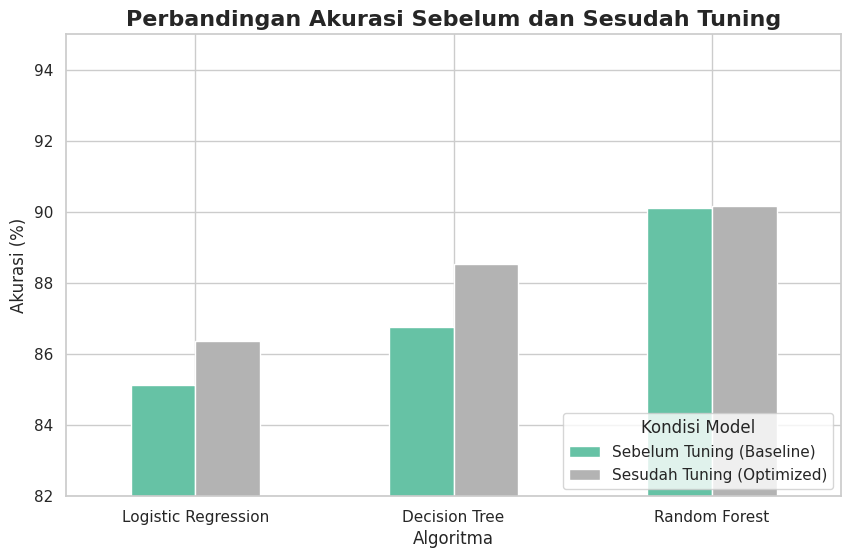

=== Tabel Komparasi Akurasi ===


,Algoritma,Sebelum Tuning (Baseline),Sesudah Tuning (Optimized)
0,Logistic Regression,85.135768,86.376404
1,Decision Tree,86.750936,88.529963
2,Random Forest,90.098315,90.168539


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

df_komparasi = pd.DataFrame({
    'Algoritma': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Sebelum Tuning (Baseline)': [
        hasil_awal_akurasi['Logistic Regression (90:10)'] * 100,
        hasil_awal_akurasi['Decision Tree (90:10)'] * 100,
        hasil_awal_akurasi['Random Forest (90:10)'] * 100
    ],
    'Sesudah Tuning (Optimized)': [
        accuracy_score(y_test, lr_juara.predict(X_test)) * 100,
        accuracy_score(y_test, dt_juara.predict(X_test)) * 100,
        accuracy_score(y_test, rf_juara.predict(X_test)) * 100
    ]
})

ax = df_komparasi.plot(x='Algoritma', kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Perbandingan Akurasi Sebelum dan Sesudah Tuning', fontsize=16, fontweight='bold')
plt.ylabel('Akurasi (%)')
plt.xlabel('Algoritma')
plt.ylim(82, 95)
plt.xticks(rotation=0)
plt.legend(title='Kondisi Model', loc='lower right')
plt.show()

print("=== Tabel Komparasi Akurasi ===")
display(df_komparasi)

Dari tabel dan grafik perbandingan, terlihat bahwa:
- Hyperparameter tuning memberikan peningkatan akurasi pada semua model
- Random Forest konsisten sebagai model terbaik baik sebelum maupun sesudah tuning
- Gap antara model linear (Logistic Regression) dan model ensemble (Random Forest) cukup signifikan, yang menunjukkan bahwa hubungan antara fitur dan tipe MBTI bersifat non-linear

### 9. Kesimpulan

Dari keseluruhan proses klasifikasi 16 tipe kepribadian MBTI yang telah dilakukan, diperoleh beberapa kesimpulan:

1. **Model terbaik**: Random Forest mencapai akurasi tertinggi yaitu **90.17%** pada rasio 90:10. Decision Tree berada di posisi kedua, diikuti Logistic Regression. Keunggulan Random Forest disebabkan oleh sifat *ensemble learning*-nya yang menggabungkan banyak pohon keputusan sehingga lebih robust terhadap variasi data.

2. **Pengaruh hyperparameter tuning**: Proses tuning menggunakan `GridSearchCV` dan `RandomizedSearchCV` memberikan peningkatan akurasi yang signifikan terutama pada Logistic Regression dan Decision Tree. Pada Random Forest, peningkatan relatif kecil karena performa baseline-nya sudah cukup tinggi.

3. **Keputusan preprocessing**: Outlier pada dataset ini tidak dihapus karena berdasarkan eksperimen, penghapusan outlier justru menurunkan akurasi. Hal ini menunjukkan bahwa nilai-nilai ekstrem pada data psikometri merupakan variasi alami dari perilaku manusia, bukan anomali. Preprocessing yang dilakukan adalah standarisasi Z-Score dan stratified splitting untuk menjaga distribusi kelas tetap merata.

4. **Pencapaian pada klasifikasi multiclass**: Akurasi ≥90% pada 16 kelas target (probabilitas tebakan acak hanya 6.25%) menunjukkan bahwa fitur-fitur psikometri yang digunakan memiliki daya prediksi yang baik terhadap tipe kepribadian MBTI. Sisa kesalahan prediksi kemungkinan disebabkan oleh overlap karakteristik antar tipe MBTI yang memang terjadi secara alami.

### 10. Export Model

In [65]:
import joblib
import os

save_path = os.path.join("..", "models")
os.makedirs(save_path, exist_ok=True)

joblib.dump(rf_juara, os.path.join(save_path, "model.pkl"))
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))

print("Model dan scaler berhasil disimpan ke folder models/")

Model dan scaler berhasil disimpan ke folder models/
